In [ ]:
library(sf)
library(ggplot2)

# Set the path to your GeoPackage file
gpkg_path <- "D:\FarmersDataLab\Robot Interseeding in Corn (RISC)\2025\GIS\RISC_2025_field_plan.gpkg"

# List all layers in the GeoPackage
layers <- st_layers(gpkg_path)
print(layers)

# Choose the layer you want (replace 'your_layer_name' with the actual layer name)
chosen_layer <- "corn_rows_line_N"

# Read the chosen layer
sf_data <- st_read(gpkg_path, layer = chosen_layer)

# Visualize the layer
ggplot(sf_data) +
    geom_sf() +
    ggtitle(paste("Layer:", chosen_layer))

NameError: name 'library' is not defined

['Corn_row_points_2N', 'Corn_row_points_1N', 'corn_rows_line_S', 'corn_rows_line_N']


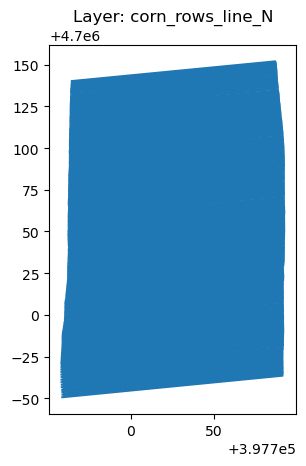

In [6]:
import geopandas as gpd
import fiona

import matplotlib.pyplot as plt

# Set the path to your GeoPackage file
gpkg_path = r"D:\FarmersDataLab\Robot Interseeding in Corn (RISC)\2025\GIS\RISC_2025_field_plan.gpkg"

# List all layers in the GeoPackage
layers = fiona.listlayers(gpkg_path)
print(layers)

# Choose the layer you want
chosen_layer = "corn_rows_line_N"

# Read the chosen layer
gdf = gpd.read_file(gpkg_path, layer=chosen_layer)

# Visualize the layer
gdf.plot()
plt.title(f"Layer: {chosen_layer}")
plt.show()

In [26]:
gdf["treatment_plan1"] = ""
gdf["treatment_plan2"] = ""
gdf["treatment_plan3"] = ""

In [28]:
# Define the treatment sequence for Plan 1
treatment_sequence = [
    "Clover-Pre-Seeding", "Buffer",
    "Clover-Rowbot", "Buffer",
    "Clover-Drone", "Buffer",
    "Clover-Postharvest", "Buffer",
    "Control", "Buffer",
    "Rye-Pre-Seeding", "Buffer",
    "Rye-Rowbot", "Buffer",
    "Rye-Drone", "Buffer",
    "Rye-Postharvest", "Buffer",
    "Control", "Buffer"
]

# Each treatment (or buffer) is assigned to 8 rows, except "Rye" which is assigned to 8 rows (since it is not followed by Buffer)
rows_per_treatment = 8

# Build the full treatment plan list for the length of gdf
plan1 = []
i = 0
while len(plan1) < len(gdf):
    for treatment in treatment_sequence:
        plan1.extend([treatment] * rows_per_treatment)
        if len(plan1) >= len(gdf):
            break

# Assign to the DataFrame (truncate if plan1 is longer than gdf)
gdf["treatment_plan1"] = plan1[:len(gdf)]

In [29]:
# Build treatment plan 2 starting from the end of gdf
plan2 = []
while len(plan2) < len(gdf):
    for treatment in treatment_sequence:
        plan2.extend([treatment] * rows_per_treatment)
        if len(plan2) >= len(gdf):
            break

# Assign reversed plan2 to the DataFrame (so the sequence starts from the end)
gdf["treatment_plan2"] = list(reversed(plan2[:len(gdf)]))

In [30]:
# For treatment_plan3, assign all 20 values (including "Buffer") to the middle 160 rows, rest empty
num_treatments = len(treatment_sequence)  # 20
rows_per_treatment_plan3 = 8
total_plan3_rows = num_treatments * rows_per_treatment_plan3  # 160

middle_start = (len(gdf) - total_plan3_rows) // 2
middle_end = middle_start + total_plan3_rows

plan3 = [""] * len(gdf)
idx = middle_start
for treatment in treatment_sequence:
    for _ in range(rows_per_treatment_plan3):
        if idx < len(gdf):
            plan3[idx] = treatment
            idx += 1

gdf["treatment_plan3"] = plan3

In [32]:
# Keep only the first 160 rows for treatment_plan1, set the rest to empty
gdf.loc[160:, "treatment_plan1"] = ""

# Keep only the last 160 rows for treatment_plan2, set the rest to empty
gdf.loc[:(len(gdf) - 160 - 1), "treatment_plan2"] = ""

In [36]:
import random

# Helper function to randomize treatments except "Buffer"
def randomize_treatments(plan):
    # Find indices and values of non-buffer treatments, grouped by 8
    group_size = 8
    groups = [plan[i:i+group_size] for i in range(0, len(plan), group_size)]
    non_buffer_group_indices = [i for i, group in enumerate(groups) if all(t != "Buffer" and t != "" for t in group)]
    non_buffer_groups = [groups[i] for i in non_buffer_group_indices]
    random.shuffle(non_buffer_groups)
    # Rebuild groups with randomized non-buffer groups, buffers in place
    randomized_groups = groups.copy()
    for idx, group in zip(non_buffer_group_indices, non_buffer_groups):
        randomized_groups[idx] = group
    # Flatten back to single list
    randomized = [item for group in randomized_groups for item in group]
    return randomized[:len(plan)]
    non_buffer_indices = [i for i, t in enumerate(plan) if t != "Buffer" and t != ""]
    non_buffer_treatments = [plan[i] for i in non_buffer_indices]
    random.shuffle(non_buffer_treatments)
    # Create new plan with randomized treatments, buffers in place
    randomized = plan.copy()
    for idx, treatment in zip(non_buffer_indices, non_buffer_treatments):
        randomized[idx] = treatment
    return randomized

# Plan 1: randomize first 160 rows
plan1_randomized = gdf["treatment_plan1"].tolist()
plan1_randomized[:160] = randomize_treatments(plan1_randomized[:160])
gdf["randomized_plan_1"] = plan1_randomized

# Plan 2: randomize last 160 rows
plan2_randomized = gdf["treatment_plan2"].tolist()
plan2_randomized[-160:] = randomize_treatments(plan2_randomized[-160:])
gdf["randomized_plan_2"] = plan2_randomized

# Plan 3: randomize middle 160 rows
plan3_randomized = gdf["treatment_plan3"].tolist()
plan3_randomized[middle_start:middle_end] = randomize_treatments(plan3_randomized[middle_start:middle_end])
gdf["randomized_plan_3"] = plan3_randomized

In [37]:
# Save the edited GeoDataFrame back to the GeoPackage, overwriting the chosen layer
gdf.to_file(gpkg_path, layer=chosen_layer, driver="GPKG")

In [39]:
import geopandas as gpd
import random

def assign_treatments_to_layer(
    gpkg_path,
    layer_name,
    unique_col,
    treatment_sequence,
    rows_per_treatment=8,
    plan3_middle=None,
    save=True
):
    """
    Assigns randomized treatment plans to a layer in a GeoPackage.

    Parameters:
        gpkg_path (str): Path to the GeoPackage.
        layer_name (str): Name of the layer to process.
        unique_col (str): Column to use as the unique identifier.
        treatment_sequence (list): List of treatments (with "Buffer" as needed).
        rows_per_treatment (int): Number of rows per treatment group.
        plan3_middle (int, optional): Number of rows in the middle for plan 3. If None, uses len(treatment_sequence) * rows_per_treatment.
        save (bool): If True, saves the result back to the GeoPackage.

    Returns:
        geopandas.GeoDataFrame: The updated GeoDataFrame.
    """

    gdf = gpd.read_file(gpkg_path, layer=layer_name)
    gdf = gdf.sort_values(by=unique_col).reset_index(drop=True)

    # Plan 1
    plan1 = []
    while len(plan1) < len(gdf):
        for treatment in treatment_sequence:
            plan1.extend([treatment] * rows_per_treatment)
            if len(plan1) >= len(gdf):
                break
    gdf["treatment_plan1"] = plan1[:len(gdf)]

    # Plan 2 (reverse)
    plan2 = []
    while len(plan2) < len(gdf):
        for treatment in treatment_sequence:
            plan2.extend([treatment] * rows_per_treatment)
            if len(plan2) >= len(gdf):
                break
    gdf["treatment_plan2"] = list(reversed(plan2[:len(gdf)]))

    # Plan 3 (middle)
    num_treatments = len(treatment_sequence)
    if plan3_middle is None:
        plan3_middle = num_treatments * rows_per_treatment
    middle_start = (len(gdf) - plan3_middle) // 2
    middle_end = middle_start + plan3_middle
    plan3 = [""] * len(gdf)
    idx = middle_start
    for treatment in treatment_sequence:
        for _ in range(rows_per_treatment):
            if idx < len(gdf):
                plan3[idx] = treatment
                idx += 1
    gdf["treatment_plan3"] = plan3

    # Restrict plan1 and plan2 to 160 rows (or plan3_middle)
    gdf.loc[plan3_middle:, "treatment_plan1"] = ""
    gdf.loc[:(len(gdf) - plan3_middle - 1), "treatment_plan2"] = ""

    # Helper for randomization
    def randomize_treatments(plan):
        group_size = rows_per_treatment
        groups = [plan[i:i+group_size] for i in range(0, len(plan), group_size)]
        non_buffer_group_indices = [i for i, group in enumerate(groups) if all(t != "Buffer" and t != "" for t in group)]
        non_buffer_groups = [groups[i] for i in non_buffer_group_indices]
        random.shuffle(non_buffer_groups)
        randomized_groups = groups.copy()
        for idx, group in zip(non_buffer_group_indices, non_buffer_groups):
            randomized_groups[idx] = group
        randomized = [item for group in randomized_groups for item in group]
        return randomized[:len(plan)]

    # Randomize plans
    plan1_randomized = gdf["treatment_plan1"].tolist()
    plan1_randomized[:plan3_middle] = randomize_treatments(plan1_randomized[:plan3_middle])
    gdf["randomized_plan_1"] = plan1_randomized

    plan2_randomized = gdf["treatment_plan2"].tolist()
    plan2_randomized[-plan3_middle:] = randomize_treatments(plan2_randomized[-plan3_middle:])
    gdf["randomized_plan_2"] = plan2_randomized

    plan3_randomized = gdf["treatment_plan3"].tolist()
    plan3_randomized[middle_start:middle_end] = randomize_treatments(plan3_randomized[middle_start:middle_end])
    gdf["randomized_plan_3"] = plan3_randomized

    if save:
        gdf.to_file(gpkg_path, layer=layer_name, driver="GPKG")

    return gdf

In [ ]:
# Call the assign_treatments_to_layer function for the "corn_rows_line_S" layer
assign_treatments_to_layer(
    gpkg_path=gpkg_path,
    layer_name="corn_rows_line_S",
    unique_col="fid",
    treatment_sequence=treatment_sequence,
    rows_per_treatment=rows_per_treatment,
    save=True
)

KeyError: 'vertex_id'

In [17]:
gdf

,id,uniq_id,AUTO,ne_id,fid_2,uniq_id_2,xcoord,ycoord,geometry,treatment_plan1,treatment_plan2,treatment_plan3
0,NaN,0,1.0,1,1,1,397787.035769,4.700152e+06,"LINESTRING (397664.074 4700140.087, 397787.036...",Clover-Pre-Seeding,Rye-Pre-Seeding,
1,NaN,0,2.0,2,2,2,397787.444056,4.700151e+06,"LINESTRING (397664.043 4700139.311, 397787.444...",Clover-Pre-Seeding,Rye-Pre-Seeding,
2,NaN,0,3.0,3,3,3,397787.546127,4.700151e+06,"LINESTRING (397664.043 4700138.582, 397787.546...",Clover-Pre-Seeding,Rye-Pre-Seeding,
3,NaN,0,4.0,4,4,4,397787.597163,4.700150e+06,"LINESTRING (397663.981 4700137.790, 397787.597...",Clover-Pre-Seeding,Rye-Pre-Seeding,
4,NaN,0,5.0,5,5,5,397787.659540,4.700149e+06,"LINESTRING (397663.919 4700137.029, 397787.660...",Clover-Pre-Seeding,Rye-Pre-Seeding,
...,...,...,...,...,...,...,...,...,...,...,...,...
243,NaN,0,244.0,245,246,245,397791.586463,4.699966e+06,"LINESTRING (397659.160 4699952.808, 397791.586...",Rye-Pre-Seeding,Clover-Pre-Seeding,
244,NaN,0,245.0,246,247,246,397791.563780,4.699965e+06,"LINESTRING (397658.442 4699952.116, 397791.564...",Rye-Pre-Seeding,Clover-Pre-Seeding,
245,NaN,0,246.0,247,248,247,397791.518415,4.699964e+06,"LINESTRING (397659.320 4699951.371, 397791.518...",Rye-Pre-Seeding,Clover-Pre-Seeding,
246,NaN,0,247.0,248,249,248,397791.450367,4.699964e+06,"LINESTRING (397658.309 4699950.546, 397791.450...",Rye-Pre-Seeding,Clover-Pre-Seeding,


In [4]:
# --- Target pages ---
urls = [f"https://www.sbir.gov/awards?page={i}" for i in range(11)]  # pages 0..10

print("The urls are "/n.join(urls) )

NameError: name 'n' is not defined